# (노트) Pytorch MLP (MNIST 3,7)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

In [ ]:
!conda install pytorch torchvision torchaudio cudatoolkit=11.1 -c pytorch -c nvidia -y 

Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: - 
Found conflicts! Looking for incompatible packages.
This can take several minutes.  Press CTRL-C to abort.
Examining conflict for google-auth-oauthlib dash cachetools pyopenssl jsonsche- 

### import 

In [1]:
import torch 
from fastai.vision.all import *

/home/cgb4/anaconda3/envs/py38r40/lib/python3.8/site-packages/torch/cuda/__init__.py:106: UserWarning: 
NVIDIA GeForce RTX 3090 with CUDA capability sm_86 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_70.
If you want to use the NVIDIA GeForce RTX 3090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(incompatible_device_warn.format(device_name, capability, " ".join(arch_list), device_name))


In [2]:
import graphviz

In [3]:
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"' + s + '; }')

### data

`-` download data 

In [4]:
path = untar_data(URLs.MNIST_SAMPLE)

In [5]:
path.ls()

(#3) [Path('/home/cgb4/.fastai/data/mnist_sample/labels.csv'),Path('/home/cgb4/.fastai/data/mnist_sample/train'),Path('/home/cgb4/.fastai/data/mnist_sample/valid')]

`-` list

In [36]:
threes=(path/'train'/'3').ls()
sevens=(path/'train'/'7').ls()

`-` list $\to$ image 

In [37]:
Image.open(threes[0])

`-` image $\to$ tensor

In [38]:
tensor(Image.open(threes[0]))

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   5,  70, 128, 200, 217,
         183, 174,  36,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,  1

- tensor는 fastai에서 구현한 함수. 리턴값은 파이토치에서 우리가 쓰던 그 텐서

`-` 여러개를 처리하여보자. 

In [39]:
seven_tensor = torch.stack([tensor(Image.open(i)) for i in sevens]).float()/255
three_tensor = torch.stack([tensor(Image.open(i)) for i in threes]).float()/255

`-` $X$와 $y$를 만들자.

In [40]:
seven_tensor.shape, three_tensor.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

In [41]:
y=torch.tensor([0.0]*6265 + [1.0]*6131).reshape(12396,1)

In [42]:
X=torch.vstack([seven_tensor,three_tensor])

In [43]:
X=X.reshape(12396,28*28)

In [44]:
X.shape

torch.Size([12396, 784])

In [45]:
y.shape

torch.Size([12396, 1])

### 모형

${\bf X} \to {\bf WX}+{\bf b} \to f({\bf WX} +{\bf b})  \to  \dots \to {\bf y}$

- ${\bf X}=12396 \times 784$ matrix 
- ${\bf y}=12396 \times 1$ (col) vector

`-` 모형을 어떻게 세우는가? (로지스틱처럼 이론적으로 탄탄한 모형이 있는가?? $\to$ 없다) 

- 아키텍처: 적당히 깊게.. + 적당히 넓게.. + 표현력이 충분하면서도.. + 과적합은 하지 않도록 (저도 잘 모르겠어요) 
- 손실함수: BCEloss
- 옵티마이저: ADAM 

`-` 교재의 모형

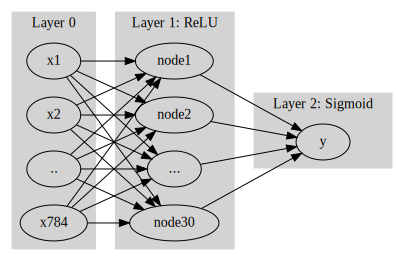

In [16]:
#collapse
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: ReLU"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "y"
    "node2" -> "y"
    "..." -> "y"
    "node30" -> "y"
    label = "Layer 2: Sigmoid"
}
''')

`-` fastai 교재의 모형을 수식으로 표현하면? 

${\bf\hat{y}}= Sigmoid\big(ReLU({\bf XW^{(1)} + b^{(1)}}){\bf W}^{(2)}+b^{(2)}\big)$


- ${\bf y}: n \times 1$

- $[{\bf 1}\quad {\bf X}]: n \times (1+784)$ 

- $\begin{bmatrix} {\bf b}^{(1)} \\ {\bf W}^{(1)} \end{bmatrix} : (1+784) \times 30 $ 

- $ReLU({\bf XW^{(1)} + b^{(1)}}) : n \times 30$ 

- $\begin{bmatrix} {\bf b}^{(2)} \\ {\bf W}^{(2)} \end{bmatrix} : (1+30) \times 1 $ 

`-` 그럼 이제 풀어보자! (아키텍처만 만들어주면 금방푼다) 

#### 풀이1

In [17]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1),
    torch.nn.Sigmoid()
)
optimizer=torch.optim.Adam(net.parameters())

In [18]:
for epoc in range(200): 
    ## 1 
    yhat=net(X) 
    ## 2 
    loss= -torch.mean(y*torch.log(yhat) + (1-y)*torch.log(1-yhat)) ## BCEloss
    #loss= loss_fn(y,yhat)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step() 
    net.zero_grad()

In [19]:
list(net.parameters())

[Parameter containing:
 tensor([[ 0.0184, -0.0158, -0.0069,  ...,  0.0068, -0.0041,  0.0025],
         [-0.0274, -0.0224, -0.0309,  ..., -0.0029,  0.0013, -0.0167],
         [ 0.0282, -0.0095, -0.0340,  ..., -0.0141,  0.0056, -0.0335],
         ...,
         [ 0.0267,  0.0186, -0.0326,  ...,  0.0047, -0.0072, -0.0301],
         [-0.0190,  0.0291,  0.0221,  ...,  0.0067,  0.0206,  0.0151],
         [ 0.0226,  0.0331,  0.0182,  ...,  0.0150,  0.0278, -0.0073]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0098,  0.0315,  0.0363, -0.0093,  0.1433,  0.0175,  0.0139, -0.0237,
          0.0323,  0.0351, -0.0125,  0.0443,  0.0176,  0.0745,  0.0098,  0.0042,
          0.0361,  0.0394,  0.0534,  0.0175,  0.0567,  0.0148,  0.0459,  0.0648,
          0.0009, -0.0279,  0.0972,  0.0478,  0.0612,  0.0504],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.2154,  0.1926,  0.2019,  0.1671, -0.1840, -0.0726, -0.1608,  0.1046,
          -0.2522, -0.2444,  0.1257, -0.181

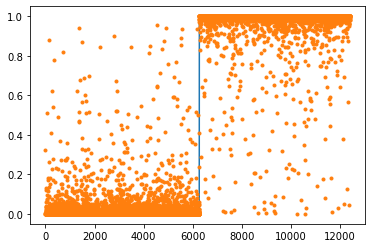

In [20]:
plt.plot(y)
plt.plot(yhat.data,'.')

In [21]:
ypred= yhat>0.5

In [22]:
sum(ypred==y)/12396

tensor([0.9893])

#### 풀이2: 내장된 손실함수를 이용

In [23]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1)
    #torch.nn.Sigmoid()
)
loss_fn=torch.nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(net.parameters())

In [24]:
for epoc in range(200): 
    ## 1 
    yhat=net(X) 
    ## 2 
    loss= loss_fn(yhat,y)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step() 
    net.zero_grad()

In [25]:
list(net.parameters())

[Parameter containing:
 tensor([[ 0.0184, -0.0158, -0.0069,  ...,  0.0068, -0.0041,  0.0025],
         [-0.0274, -0.0224, -0.0309,  ..., -0.0029,  0.0013, -0.0167],
         [ 0.0282, -0.0095, -0.0340,  ..., -0.0141,  0.0056, -0.0335],
         ...,
         [ 0.0267,  0.0186, -0.0326,  ...,  0.0047, -0.0072, -0.0301],
         [-0.0190,  0.0291,  0.0221,  ...,  0.0067,  0.0206,  0.0151],
         [ 0.0226,  0.0331,  0.0182,  ...,  0.0150,  0.0278, -0.0073]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0098,  0.0315,  0.0363, -0.0093,  0.1433,  0.0175,  0.0139, -0.0237,
          0.0323,  0.0351, -0.0125,  0.0443,  0.0176,  0.0745,  0.0098,  0.0042,
          0.0361,  0.0394,  0.0534,  0.0175,  0.0567,  0.0148,  0.0459,  0.0648,
          0.0009, -0.0279,  0.0972,  0.0478,  0.0612,  0.0504],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.2154,  0.1926,  0.2019,  0.1671, -0.1840, -0.0726, -0.1608,  0.1046,
          -0.2522, -0.2444,  0.1257, -0.181

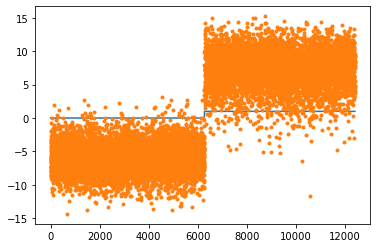

In [26]:
plt.plot(y)
plt.plot(yhat.data,'.')

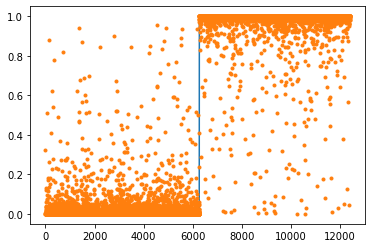

In [27]:
f=torch.nn.Sigmoid()
plt.plot(y)
plt.plot(f(yhat.data),'.')

#### 풀이3: 내장된 손실함수이용 + GPU를 이용

In [28]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(28*28,30),
    torch.nn.ReLU(),
    torch.nn.Linear(30,1)
)
net.to("cuda:0")

Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=1, bias=True)
)

In [29]:
X_gpu=X.to("cuda:0")
y_gpu=y.to("cuda:0")
optimizer=torch.optim.Adam(net.parameters())

In [30]:
for epoc in range(200): 
    ## 1 
    yhat_gpu=net(X_gpu) 
    ## 2 
    loss= loss_fn(yhat_gpu,y_gpu)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step() 
    net.zero_grad()

In [31]:
list(net.parameters())

[Parameter containing:
 tensor([[ 0.0184, -0.0158, -0.0069,  ...,  0.0068, -0.0041,  0.0025],
         [-0.0274, -0.0224, -0.0309,  ..., -0.0029,  0.0013, -0.0167],
         [ 0.0282, -0.0095, -0.0340,  ..., -0.0141,  0.0056, -0.0335],
         ...,
         [ 0.0267,  0.0186, -0.0326,  ...,  0.0047, -0.0072, -0.0301],
         [-0.0190,  0.0291,  0.0221,  ...,  0.0067,  0.0206,  0.0151],
         [ 0.0226,  0.0331,  0.0182,  ...,  0.0150,  0.0278, -0.0073]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.0098,  0.0315,  0.0363, -0.0093,  0.1433,  0.0175,  0.0139, -0.0237,
          0.0323,  0.0351, -0.0125,  0.0443,  0.0176,  0.0745,  0.0098,  0.0042,
          0.0361,  0.0394,  0.0534,  0.0175,  0.0567,  0.0148,  0.0459,  0.0648,
          0.0009, -0.0279,  0.0972,  0.0478,  0.0612,  0.0504], device='cuda:0',
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.2154,  0.1926,  0.2019,  0.1671, -0.1840, -0.0726, -0.1608,  0.1046,
         

`-` 그림을 그릴려면 cpu로 옮겨줘야 한다. 

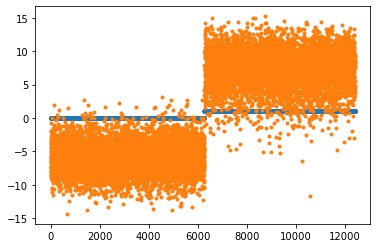

In [32]:
plt.plot(y_gpu.data.to("cpu"),'.')
plt.plot(yhat_gpu.data.to("cpu").numpy(),'.')